In [1]:
library(SingleCellExperiment)
library(zellkonverter)
library(scuttle)   # aggregateAcrossCells
library(edgeR)
library(Matrix)
library(dplyr)
library(pheatmap)

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics

Loading required package: matrixStats


Attaching package: ‘MatrixGenerics’


The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles, rowRanges

In [2]:
sce <- readH5AD("data/snRNA_data/RGC_raw_counts.h5ad")

In [3]:
assayNames(sce)[assayNames(sce) == "X"] <- "counts"

In [5]:
sce$time <- as.character(sce$condition)
sce$time[sce$time %in% 'Contralateral'] <- 0
sce$time[sce$time %in% 'COH_2w'] <- 2
sce$time[sce$time %in% 'COH_4w'] <- 4
sce$time[sce$time %in% 'COH_8w'] <- 8

In [6]:
counts_mat <- as.matrix(counts(sce))
md <- as.data.frame(colData(sce))

cell_order <- colnames(counts_mat)
md <- md[match(cell_order, rownames(md)), ]

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 3.0 GiB”


In [7]:
samples <- unique(md$sample)

pseudo_counts <- sapply(samples, function(s) {
  idx <- which(md$sample == s)
  Matrix::rowSums(counts_mat[, idx, drop = FALSE])
})

colnames(pseudo_counts) <- samples
pseudo_counts <- as.matrix(pseudo_counts)

In [8]:
sample_time <- sapply(samples, function(s) {
  unique(md$time[md$sample == s])[1]
})

In [9]:
names(sample_time) <- samples
sample_time <- sample_time[colnames(pseudo_counts)]

In [10]:
logCPM <- edgeR::cpm(pseudo_counts, log=TRUE, prior.count=1)

In [11]:
time0_cols <- which(sample_time == "0")

baseline_mean <- rowMeans(logCPM[, time0_cols, drop=FALSE])
baseline_sd <- apply(logCPM[, time0_cols, drop=FALSE], 1, sd)
baseline_sd[baseline_sd == 0] <- 1e-6

logCPM_z <- sweep(logCPM, 1, baseline_mean, "-")
logCPM_z <- sweep(logCPM_z, 1, baseline_sd, "/")
logCPM_z <- pmin(pmax(logCPM_z, -5), 5)

In [12]:
time_num <- as.numeric(as.character(sample_time))

In [13]:
genes <- rownames(logCPM_z)
pvals <- numeric(length(genes))

In [14]:
library(mgcv)

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


The following object is masked from ‘package:IRanges’:

    collapse


This is mgcv 1.9-3. For overview type 'help("mgcv-package")'.



In [15]:
for (i in seq_along(genes)) {
  y <- as.numeric(logCPM_z[i, ])
  df <- data.frame(expr=y, time=time_num)
  fit <- try(mgcv::gam(expr ~ s(time, k=4), data=df, method="REML"), silent=TRUE)
  if (class(fit)[1] == "try-error") {
    pvals[i] <- NA
  } else {
    ssum <- summary(fit)$s.table
    if (!is.null(ssum)) {
      pvals[i] <- ssum[1, "p-value"]
    } else {
      pvals[i] <- NA
    }
  }
}

In [16]:
sig_genes <- genes[which(!is.na(pvals) & pvals < 0.01)]

In [17]:
mat_sig <- logCPM_z[sig_genes, , drop=FALSE]

mat_time_means <- cbind(
  rowMeans(mat_sig[, sample_time=="0", drop=FALSE]),  
  rowMeans(mat_sig[, sample_time=="2", drop=FALSE]),
  rowMeans(mat_sig[, sample_time=="4", drop=FALSE]),
  rowMeans(mat_sig[, sample_time=="8", drop=FALSE])
)
colnames(mat_time_means) <- c("0","2","4","8")
rownames(mat_time_means) <- sig_genes

mat_kmeans <- t(scale(t(mat_time_means)))
mat_kmeans[is.na(mat_kmeans)] <- 0

In [18]:
set.seed(0)
km <- kmeans(mat_kmeans, centers=3, nstart=20)
gene_cluster <- km$cluster

In [20]:
plot_cols <- which(sample_time %in% c("0","2","4","8"))
plot_order <- order(as.numeric(as.character(sample_time[plot_cols])),
                    colnames(logCPM)[plot_cols])
plot_samples <- colnames(logCPM)[plot_cols][plot_order]

mat_plot <- logCPM_z[sig_genes, plot_samples, drop=FALSE]

row_order <- order(gene_cluster[rownames(mat_plot)])
mat_plot <- mat_plot[row_order, ]
row_clustervec <- gene_cluster[rownames(mat_plot)]

ann_row <- data.frame(Cluster=factor(row_clustervec))
rownames(ann_row) <- rownames(mat_plot)

ann_col <- data.frame(Time=factor(sample_time[plot_samples], levels=c("0","2","4","8")))
rownames(ann_col) <- plot_samples

ann_col$Time <- factor(ann_col$Time)
ann_row$Cluster <- factor(ann_row$Cluster)

In [21]:
ann_col <- ann_col[colnames(mat_plot), , drop = FALSE]
ann_row <- ann_row[rownames(mat_plot), , drop = FALSE]

In [22]:
ann_colors <- list(Cluster = c("1" = "#1B9E77", "2" = "#D95F02", "3" = "#7570B3"),
              Time = c("2" = "#E41A1C", "4" = "#377EB8", "8" = "#4DAF4A"))

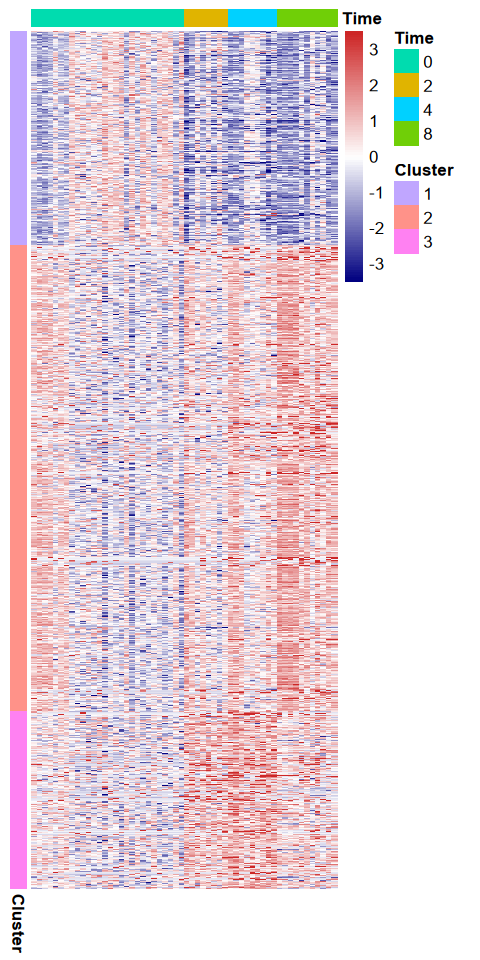

In [23]:
options(repr.plot.width=4, repr.plot.height=8)
color_breaks <- seq(-3.5, 3.5, length.out = 101)
pheatmap(mat_plot,
         cluster_rows=FALSE,
         cluster_cols=FALSE,
         show_rownames=FALSE,
         show_colnames=FALSE,
         annotation_row=ann_row,
         annotation_col=ann_col,
         scale="none",
         color=colorRampPalette(c("navy","white","firebrick3"))(100),breaks = color_breaks)

In [24]:
df <- as.data.frame(mat_time_means)
df$gene <- rownames(df)
df$cluster <- gene_cluster[df$gene]

In [25]:
df2 <- df %>% 
  select(gene, cluster, `0`, `2`, `4`, `8`)

In [26]:
library(ggplot2)
library(dplyr)
library(tidyr)

df_long <- df2 %>%
  pivot_longer(cols = c(`0`,`2`,`4`,`8`),
               names_to = "time",
               values_to = "zscore") %>%
  mutate(time = factor(time, levels = c("0","2","4","8")),
         cluster = factor(cluster))


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’:

    expand, pack, unpack


The following object is masked from ‘package:S4Vectors’:

    expand




In [27]:
all_clusters <- sort(unique(df_long$cluster))

In [28]:
df_long$time <- as.numeric(as.character(df_long$time))

In [29]:
plots <- list()
for(cl in c(as.character(1:3))) {
  df_sub <- df_long %>% filter(cluster == cl)
    df_avg <- df_sub %>%
      group_by(time) %>%
      summarize(mean_z = mean(zscore), .groups = "drop") %>%
      arrange(time)
  a <- max(df_avg$mean_z)+2
  b <- a-5
  p <- ggplot(df_sub, aes(x = time, y = zscore)) +
    geom_point(alpha = 0.4, size = 1.4) + 
    geom_line(data = df_avg, aes(x = time, y = mean_z),
              color = "red", size = 1.2) +
    coord_cartesian(ylim = c(b, a)) +
    scale_x_continuous(limits = c(0, 9),breaks = c(0, 2, 4, 8)) +
    theme_bw() +
    ggtitle(paste("Cluster", cl)) +
    xlab("Time") + ylab("Z-score") +
    theme(plot.title = element_text(hjust = 0.5))
  
  plots[[as.character(cl)]] <- p
}

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


In [30]:
library(patchwork)

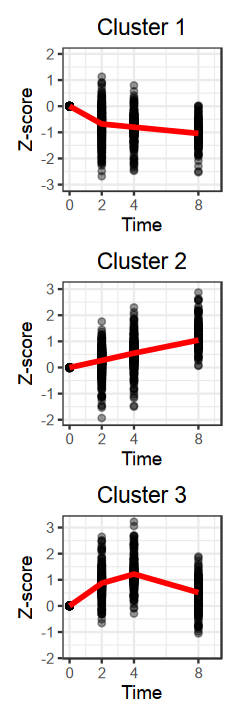

In [31]:
options(repr.plot.width=2, repr.plot.height=6)
combined_plot <- (plots[[1]]) /
                 (plots[[2]]) /
                 (plots[[3]])
combined_plot